In [ ]:
!git clone https://github.com/rasbt/reasoning-from-scratch.git
%cd reasoning-from-scratch
!pip install -r requirements.txt
!pip install sympy antlr4-python3-runtime==4.11.1
!pip install antlr4-python3-runtime

fatal: destination path 'reasoning-from-scratch' already exists and is not an empty directory.
/content/reasoning-from-scratch


# Evaluate Reasoning Model -> Qwen3 MATH-500 Evaluation Script

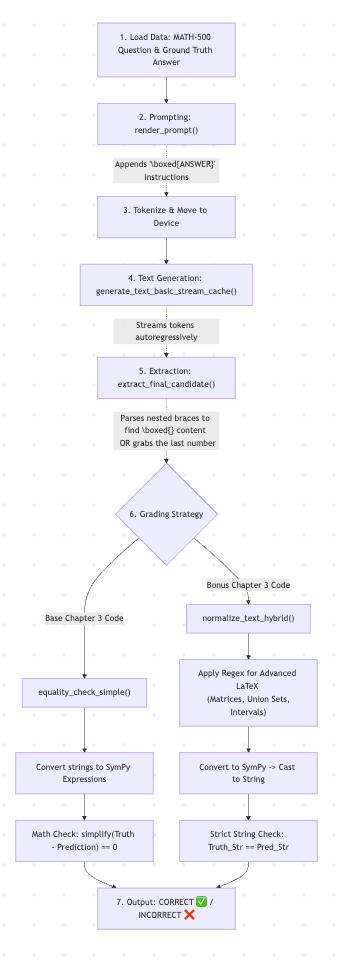

## What this script does
Runs the Qwen3 0.6B base model against a subset of the **MATH-500 benchmark** —
a set of competition math problems. For each problem it generates an answer,
extracts the predicted value, and grades it with **two parsers** side-by-side to
show where they disagree.

---

## 1. Parser Health-Check
Before anything runs, the script verifies the **hybrid LaTeX parser** is working
by converting `\frac{1}{2}` and checking the result is `"1/2"`.

If it fails, the parser is silently falling back to basic string matching, which
causes false negatives on any LaTeX expression. The script **halts with a
`RuntimeError`** rather than letting bad grades slip through unnoticed.

> Fix: `pip install antlr4-python3-runtime==4.11.3` then restart the session.

---

## 2. Answer Extraction

### `get_last_boxed(text)`
Finds the **last** `\boxed{}` in the model output using a **brace-depth counter**
(not regex) so nested braces like `\boxed{\frac{1}{2}}` are handled correctly.

### `extract_final_candidate(text)`
Two-stage fallback:
1. Try `get_last_boxed()` — the format explicitly requested in the prompt.
2. If absent, grab the **last number** in the text via regex (covers fractions,
   decimals, scientific notation).

---

## 3. Two Graders (run in parallel for comparison)

| Grader | How it works | Weakness |
|---|---|---|
| **Simple** (`equality_check_simple`) | Exact string match, then SymPy symbolic diff → zero | Can't parse raw LaTeX |
| **Hybrid** (`normalize_text_hybrid`) | Full LaTeX → canonical form via ANTLR4 backend, then string compare | Requires antlr4 package |

Both are shown per question so you can see exactly where the simple parser fails.

---

## 4. Prompt Format (`render_prompt`)
Zero-shot prompt that instructs the model to place its final answer in `\boxed{ANSWER}`.
This is the contract that `get_last_boxed()` relies on for extraction.

---

## 5. Evaluation Loop (`run_evaluation`)

```
For each problem:
  1. GENERATE  — stream tokens from Qwen3, collect into a list, decode to string
  2. EXTRACT   — pull raw candidate via extract_final_candidate()
  3. NORMALISE — run both candidate and ground truth through normalize_text_hybrid()
  4. GRADE     — string equality (hybrid) + SymPy check (simple), print both
```

Ends with a **Final Accuracy** score: `correct / total`.

In [3]:
import torch
import json
import re
import requests
from pathlib import Path
from sympy import simplify
from sympy.parsing import sympy_parser as spp

# ── Core inference utilities from the previous chapter (device selection + streaming generator)
from reasoning_from_scratch.ch02 import get_device, generate_text_basic_stream_cache

# ── Qwen3 model components (same as Chapter 2 setup)
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Model,
    Qwen3Tokenizer,
    QWEN_CONFIG_06_B
)

# ── Heavy-duty LaTeX normaliser (350+ lines, requires the ANTLR4 C-backend).
# Imported rather than re-implemented here because the edge-case handling is extensive.
from reasoning_from_scratch.bonus.parser import normalize_text_hybrid


# ─────────────────────────────────────────────
# 1. PARSER HEALTH-CHECK
# ─────────────────────────────────────────────
# The hybrid parser depends on antlr4-python3-runtime==4.11.3.
# If that package is missing it silently falls back to basic string matching,
# which causes false negatives on LaTeX like \frac{1}{2}.
# We catch this early by running a known conversion and halting if it's wrong.

test_latex = r"\frac{1}{2}"
backend_ok = normalize_text_hybrid(test_latex) == "1/2"

if not backend_ok:
    raise RuntimeError(
        "🚨 CRITICAL: The Hybrid LaTeX parser failed to load!\n"
        "It is attempting a silent fallback to basic string matching.\n"
        "Fix: Run `!pip install antlr4-python3-runtime==4.11.3` and RESTART the session."
    )

print("✅ LaTeX backend is successfully loaded and ready.")


# ─────────────────────────────────────────────
# 2. ANSWER EXTRACTION FROM MODEL OUTPUT
# ─────────────────────────────────────────────

def get_last_boxed(text):
    """
    Searches for the LAST occurrence of \\boxed{} in the model's raw output
    and returns its contents.

    Uses a brace-depth counter instead of a regex so that nested braces
    (e.g. \\boxed{\\frac{1}{2}}) are handled correctly — a regex would stop
    at the first closing brace and return a truncated result.

    Returns None if no \\boxed{} tag is found or if the braces are unmatched.
    """
    boxed_start_idx = text.rfind(r"\boxed")
    if boxed_start_idx == -1:
        return None  # No \boxed{} present at all

    # Advance past the "\boxed" keyword and any whitespace to reach the opening "{"
    current_idx = boxed_start_idx + len(r"\boxed")
    while current_idx < len(text) and text[current_idx].isspace():
        current_idx += 1

    if current_idx >= len(text) or text[current_idx] != "{":
        return None  # Malformed tag — no opening brace found

    current_idx += 1          # Step inside the opening "{"
    brace_depth = 1            # Track how deep we are in nested braces
    content_start_idx = current_idx

    # Walk forward until the matching closing "}" is found
    while current_idx < len(text) and brace_depth > 0:
        if text[current_idx] == "{":
            brace_depth += 1   # Entering a deeper nested brace
        elif text[current_idx] == "}":
            brace_depth -= 1   # Closing one level of nesting
        current_idx += 1

    # brace_depth == 0 means we found the correct closing brace
    return text[content_start_idx : current_idx - 1] if brace_depth == 0 else None


def extract_final_candidate(text):
    """
    Two-stage strategy for pulling a candidate answer out of raw model output:

      1. Look for \\boxed{} — the format we explicitly asked for in the prompt.
      2. If absent, fall back to grabbing the last number in the text
         (handles fractions, decimals, and scientific notation).
    """
    boxed = get_last_boxed(text.strip())
    if boxed:
        return boxed.strip().strip("$ ")  # Strip surrounding whitespace and dollar signs

    # Regex covers: fractions (1/2), integers, decimals (3.14), scientific (1e-5)
    matches = re.findall(r"-?(?:\d+/\d+|\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", text)
    return matches[-1] if matches else text


# ─────────────────────────────────────────────
# 3. MATH EQUALITY CHECKERS
# ─────────────────────────────────────────────

def equality_check_simple(expr_gtruth, expr_pred):
    """
    Baseline (Chapter 3) symbolic equality check using SymPy.

    Strategy:
      1. Exact string match — fast path for trivially equal answers.
      2. Parse both expressions with SymPy and test whether their difference
         simplifies to zero — handles equivalent forms like 0.5 vs 1/2.

    Limitations: Fails on raw LaTeX (e.g. \\frac{1}{2}) because SymPy's
    parser doesn't understand LaTeX syntax. That's what the hybrid parser
    (normalize_text_hybrid) is for.
    """
    if expr_gtruth == expr_pred:
        return True

    def parse(expr):
        # Guard against empty strings or suspiciously long inputs (likely garbled output)
        if not expr or len(expr) > 2000:
            return None
        try:
            return spp.parse_expr(
                expr,
                transformations=(
                    *spp.standard_transformations,
                    spp.implicit_multiplication_application  # Allows "2x" → "2*x"
                ),
                evaluate=True
            )
        except Exception:
            return None  # Unparseable — skip symbolic comparison

    gtruth_sym, pred_sym = parse(expr_gtruth), parse(expr_pred)

    if gtruth_sym is not None and pred_sym is not None:
        try:
            return simplify(gtruth_sym - pred_sym) == 0
        except Exception:
            pass

    return False  # Could not verify equality


# ─────────────────────────────────────────────
# 4. DATA LOADING & PROMPT FORMATTING
# ─────────────────────────────────────────────

def load_math500_test(local_path="math500_test.json"):
    """
    Loads the MATH-500 benchmark from disk, downloading it first if needed.
    Caches the file locally so subsequent runs don't require a network call.
    """
    local_path = Path(local_path)

    if not local_path.exists():
        url = (
            "https://raw.githubusercontent.com/rasbt/reasoning-from-scratch"
            "/main/ch03/01_main-chapter-code/math500_test.json"
        )
        data = requests.get(url).json()
        with local_path.open("w", encoding="utf-8") as f:
            json.dump(data, f, indent=2)

    with local_path.open("r", encoding="utf-8") as f:
        return json.load(f)


def render_prompt(problem):
    """
    Wraps a raw math problem in a zero-shot prompt that instructs the model
    to place its final answer inside a \\boxed{} tag on its own line.
    This format is what get_last_boxed() looks for during extraction.
    """
    return (
        "You are a helpful math assistant.\n"
        "Answer the question and write the final result on a new line as:\n"
        r"\boxed{ANSWER}" "\n\n"
        f"Question:\n{problem}\n\n"
        "Answer:"
    )


# ─────────────────────────────────────────────
# 5. EVALUATION ENGINE
# ─────────────────────────────────────────────

def run_evaluation(dataset_size=3):
    """
    End-to-end evaluation loop:
      1. Load model + tokenizer.
      2. For each problem, generate a response token-by-token (streaming).
      3. Extract the predicted answer and normalise both prediction and
         ground truth with the hybrid LaTeX parser.
      4. Grade with BOTH the simple SymPy checker and the hybrid parser
         so we can see where they diverge.
      5. Print per-question results and a final accuracy score.
    """
    # ── Model setup (mirrors Chapter 2) ───────────────────────────────────
    device = get_device()
    print(f"Using device: {device}")

    download_qwen3_small(kind="base", tokenizer_only=False, out_dir="qwen3")
    tokenizer = Qwen3Tokenizer(tokenizer_file_path="qwen3/tokenizer-base.json")

    model = Qwen3Model(QWEN_CONFIG_06_B)
    model.load_state_dict(
        torch.load("qwen3/qwen3-0.6B-base.pth", map_location=device, weights_only=True)
    )
    model.to(device).eval()

    # ── Load a slice of the benchmark ─────────────────────────────────────
    math_data = load_math500_test()[:dataset_size]
    num_correct = 0

    print("\nStarting Evaluation...")

    for i, row in enumerate(math_data, 1):

        # ── Generate model response ────────────────────────────────────────
        prompt = render_prompt(row["problem"])
        input_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)

        # Collect all token IDs produced by the streaming generator
        generated_ids = []
        for token in generate_text_basic_stream_cache(
            model, input_ids, max_new_tokens=256, eos_token_id=tokenizer.eos_token_id
        ):
            generated_ids.append(token.squeeze(0).item())

        gen_text = tokenizer.decode(generated_ids)

        # ── Extract & normalise ────────────────────────────────────────────
        # Step 1: Pull out the raw candidate string (\\boxed{} or last number)
        extracted = extract_final_candidate(gen_text)

        # Step 2: Normalise both prediction and ground truth with the hybrid
        #         parser so that "\\frac{1}{2}" and "0.5" both become "1/2"
        pred = normalize_text_hybrid(extracted)
        gold = normalize_text_hybrid(row["answer"])

        # ── Grade ──────────────────────────────────────────────────────────
        is_correct = (pred == gold)   # String equality after normalisation
        num_correct += int(is_correct)

        # Also grade with the simple parser to highlight where they differ
        simple_check = equality_check_simple(row["answer"], extracted)

        print(f"\n--- Question {i} ---")
        print(f"Expected : {row['answer']}")
        print(f"Extracted: {extracted}")
        print(f"Graded (Simple Parser) : {'CORRECT ✅' if simple_check else 'INCORRECT ❌'}")
        print(f"Graded (Hybrid Parser) : {'CORRECT ✅' if is_correct else 'INCORRECT ❌'}")

    print(f"\nFinal Accuracy: {num_correct}/{dataset_size} ({(num_correct / dataset_size) * 100:.1f}%)")


# ── Entry point ────────────────────────────────────────────────────────────────
run_evaluation(dataset_size=50)

✅ LaTeX backend is successfully loaded and ready.
Using NVIDIA CUDA GPU
Using device: cuda
✓ qwen3/qwen3-0.6B-base.pth already up-to-date

Starting Evaluation...

--- Question 1 ---
Expected : \left( 3, \frac{\pi}{2} \right)
Extracted: (3,\frac{\pi}{2})
Graded (Simple Parser) : INCORRECT ❌
Graded (Hybrid Parser) : CORRECT ✅

--- Question 2 ---
Expected : p - q
Extracted: p^2 - 3pq + 2q^2
Graded (Simple Parser) : INCORRECT ❌
Graded (Hybrid Parser) : INCORRECT ❌

--- Question 3 ---
Expected : \frac{14}{3}
Extracted: -\frac{1}{2}
Graded (Simple Parser) : INCORRECT ❌
Graded (Hybrid Parser) : INCORRECT ❌

--- Question 4 ---
Expected : 9
Extracted: 16
Graded (Simple Parser) : INCORRECT ❌
Graded (Hybrid Parser) : INCORRECT ❌

--- Question 5 ---
Expected : \text{Evelyn}
Extracted: 3.6
Graded (Simple Parser) : INCORRECT ❌
Graded (Hybrid Parser) : INCORRECT ❌

--- Question 6 ---
Expected : 42
Extracted: 126
Graded (Simple Parser) : INCORRECT ❌
Graded (Hybrid Parser) : INCORRECT ❌

--- Question 7